# AMD Stock Price Prediction 

## Project Topic
**Predicting AMD's Next-Day Closing Stock Price**

This notebook follows a three-phase structure:

- **Phase 1: Data Exploration & Preprocessing** — load the AMD OHLCV data and do data exploration
- **Phase 2: Feature Engineering** - engineer featurand prepare a leakage-safe train/test split
- **Phase 3: Model Selection, Training & Hyperparameter Tuning** — train and tune several regression models, including deep learning sequence models, to predict the next day's closing price.
- **Phase 3: Final Evaluation & Next-Day Prediction** — compare models, evaluate the best one on the test set, and output the actual next-day price prediction.

**Problem type:** Supervised regression (continuous target: next day's closing price).

**Models compared:** Linear Regression, Random Forest, Gradient Boosting, Simple RNN, and LSTM.


# Phase 1: Data Exploration & Preprocessing

## 1. Import Libraries

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 2. Load Dataset

The dataset was downloaded from Yahoo Finance (via `yfinance`) and contains daily OHLCV (Open, High, Low, Close, Volume) records for AMD stock. The raw CSV has two extra header rows (ticker name and blank index label) which we skip on load.

In [63]:
import yfinance as yf
import pandas as pd

# Download the latest historical data
df = yf.download(
    "AMD",
    period="10y",      # or "max"
    interval="1d",
    auto_adjust=False,
    progress=False
)

df.reset_index(inplace=True)

df = df[['Date','Open','High','Low','Close','Volume']]

print(df.tail())

Price        Date        Open        High         Low       Close    Volume
Ticker                    AMD         AMD         AMD         AMD       AMD
2508   2026-07-31  510.279999  515.619995  475.760010  476.149994  26615700
2509   2026-08-03  461.790009  490.950012  455.299988  484.640015  24422300
2510   2026-08-04  504.000000  530.130005  502.200012  518.580017  48463600
2511   2026-08-05  484.500000  502.000000  478.200012  482.049988  49615800
2512   2026-08-06  471.750000  496.720001  469.500000  489.279999  24594700


## 3. Initial Data Exploration

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2513 entries, 0 to 2512
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   (Date, )       2513 non-null   datetime64[ns]
 1   (Open, AMD)    2513 non-null   float64       
 2   (High, AMD)    2513 non-null   float64       
 3   (Low, AMD)     2513 non-null   float64       
 4   (Close, AMD)   2513 non-null   float64       
 5   (Volume, AMD)  2513 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 117.9 KB


In [65]:
df.describe()

Price,Date,Open,High,Low,Close,Volume
Ticker,,AMD,AMD,AMD,AMD,AMD
count,2513,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,2021-08-04 14:54:29.080780032,93.916307,95.918942,91.844075,93.938699,6.228415e+07
min,2016-08-08 00:00:00,5.750000,5.950000,5.660000,5.740000,7.956800e+06
25%,2019-02-06 00:00:00,25.780001,26.799999,25.250000,25.690001,3.959390e+07
50%,2021-08-04 00:00:00,83.010002,84.720001,81.529999,82.769997,5.334200e+07
75%,2024-02-02 00:00:00,122.459999,125.559998,120.629997,122.839996,7.628060e+07
max,2026-08-06 00:00:00,567.219971,584.729980,546.770020,580.909973,3.250584e+08
std,NaN,90.448655,92.795758,87.976671,90.561004,3.326647e+07


In [66]:
print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
Price   Ticker
Date              0
Open    AMD       0
High    AMD       0
Low     AMD       0
Close   AMD       0
Volume  AMD       0
dtype: int64

Duplicate rows: 0


The dataset has no missing values and no duplicate rows, so no cleaning is required beyond parsing the date column and confirming numeric types.

## 4. Visualise Closing Price and Volume Over Time

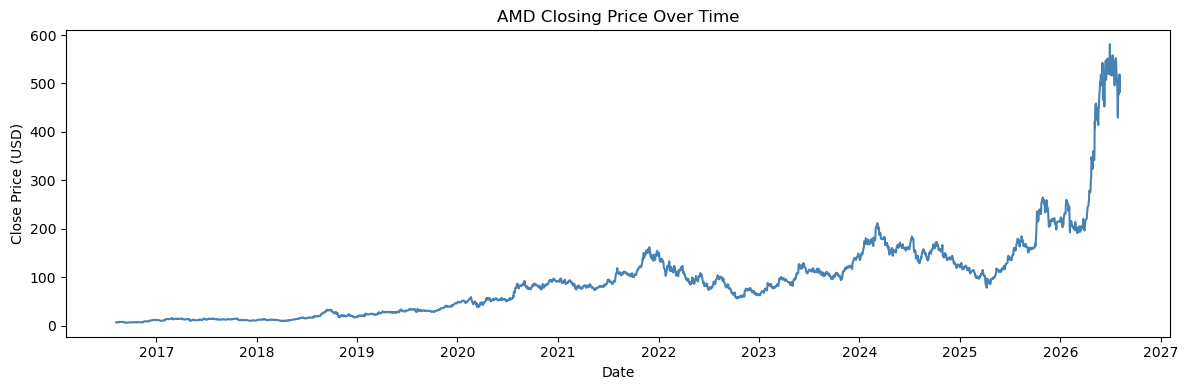

In [67]:
plt.figure(figsize=(12, 4))

plt.plot(df['Date'], df['Close'], color='steelblue')
plt.title('AMD Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')

plt.tight_layout()
plt.show()

### Interpretation

AMD's closing price grew from roughly \$14 in mid-2018 to over \$500 by 2026, including a sharp run-up and a volatile correction along the way. This long-term upward trend matters for model choice: a model needs to be able to **extrapolate** beyond the price range it was trained on, since the test period (most recent data) contains prices higher than anything seen earlier in training.

# Phase2: Feature Engineering 

Raw OHLCV data on its own gives a model very little to work with for a single day. We engineer features that are standard in stock price prediction, used by the **Linear Regression, Random Forest, and Gradient Boosting** models below:

- **Lag features**: previous 1, 2, 3, and 5 days' closing prices.
- **Moving averages & rolling volatility** (5, 10, 20-day windows).
- **Daily return**: percentage change in closing price.
- **High-Low spread and Open-Close spread**: intraday volatility.
- **Volume change**: percentage change in trading volume.
- **RSI (14-day Relative Strength Index)**: a classic momentum indicator.
- **Day of week**: possible weekly seasonality.

**Target variable:** `Target_Close_Next` — the closing price on the *following* trading day, created by shifting `Close` **backwards** by one row (`shift(-1)`).

(The RNN/LSTM models later in the notebook use a different input format — raw sequences of past closing prices — which is the standard approach for recurrent networks, so they don't use this engineered feature table.)

In [68]:
df_feat = df.copy()

# Daily return
df_feat['Return_1d'] = df_feat['Close'].pct_change()

# Lag features
for lag in [1, 2, 3, 5]:
    df_feat[f'Close_lag_{lag}'] = df_feat['Close'].shift(lag)

# Rolling moving averages and volatility
for window in [5, 10, 20]:
    df_feat[f'MA_{window}'] = df_feat['Close'].rolling(window).mean()
    df_feat[f'Volatility_{window}'] = df_feat['Close'].rolling(window).std()

# Intraday spreads
df_feat['HL_spread'] = df_feat['High'] - df_feat['Low']
df_feat['OC_spread'] = df_feat['Close'] - df_feat['Open']

# Volume change
df_feat['Volume_change'] = df_feat['Volume'].pct_change()

# RSI (14-day)
delta = df_feat['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df_feat['RSI_14'] = 100 - (100 / (1 + rs))

# Day of week (0 = Monday)
df_feat['DayOfWeek'] = df_feat['Date'].dt.dayofweek

# Target: next trading day's closing price
df_feat['Target_Close_Next'] = df_feat['Close'].shift(-1)

print('Shape after feature engineering (before dropping NaNs):', df_feat.shape)
df_feat.tail()

Shape after feature engineering (before dropping NaNs): (2513, 23)


Price,Date,Open,High,Low,Close,Volume,Return_1d,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_5,MA_5,Volatility_5,MA_10,Volatility_10,MA_20,Volatility_20,HL_spread,OC_spread,Volume_change,RSI_14,DayOfWeek,Target_Close_Next
Ticker,,AMD,AMD,AMD,AMD,AMD,,,,,,,,,,,,,,,,,
2508,2026-07-31,510.279999,515.619995,475.760010,476.149994,26615700,-0.019036,485.390015,429.559998,454.619995,521.950012,468.134003,26.228356,500.264005,40.291325,515.059001,34.980270,39.859985,-34.130005,-0.279422,40.622180,4,484.640015
2509,2026-08-03,461.790009,490.950012,455.299988,484.640015,24422300,0.017831,476.149994,485.390015,429.559998,494.950012,466.072003,23.894547,498.371005,40.562521,511.688503,34.472371,35.650024,22.850006,-0.082410,39.601013,0,518.580017
2510,2026-08-04,504.000000,530.130005,502.200012,518.580017,48463600,0.070031,484.640015,476.149994,485.390015,454.619995,478.864008,31.982666,495.786008,38.046776,511.812004,34.493463,27.929993,14.580017,0.984400,48.351134,1,482.049988
2511,2026-08-05,484.500000,502.000000,478.200012,482.049988,49615800,-0.070442,518.580017,484.640015,476.149994,429.559998,489.362006,16.731624,488.758005,32.532957,510.044005,35.092438,23.799988,-2.450012,0.023775,47.125246,2,489.279999
2512,2026-08-06,471.750000,496.720001,469.500000,489.279999,24594700,0.014998,482.049988,518.580017,484.640015,485.390015,490.140002,16.590604,483.717004,27.238916,507.172006,34.273785,27.220001,17.529999,-0.504297,49.019962,3,NaN


## 6. Handle Missing Values from Feature Engineering

Rolling windows and lag features create `NaN` values at the start of the series, and shifting the target backwards creates a `NaN` in the final row (no "next day" exists yet). We keep the **last row separately** — it has no target, but it's exactly what we need later to make a real next-day prediction — and drop `NaN` rows from the rest for model training.

In [69]:
# Save the most recent row (features exist, but no target since there's no "next day" yet)
latest_row = df_feat.iloc[[-1]].copy()
print('Latest available date in dataset:', latest_row['Date'].values[0])

# Rows usable for training/testing: everything with complete features AND a known target
df_model = df_feat.dropna().reset_index(drop=True)

print('Shape after dropping NaN rows:', df_model.shape)
print('Rows lost to rolling-window warm-up + final shifted target:', df_feat.shape[0] - df_model.shape[0])

Latest available date in dataset: 2026-08-06T00:00:00.000000000
Shape after dropping NaN rows: (2493, 23)
Rows lost to rolling-window warm-up + final shifted target: 20


## 7. Chronological Train/Test Split

Stock price data is a **time series**, so we cannot use a random train/test split — that would let the model "see the future". Instead we split **chronologically**: the earliest ~85% of rows are used for training, and the most recent ~15% are held out as a test set that always comes after the training period. This same 85/15 cutoff point is reused for the RNN/LSTM sequence data later, so all five models are judged on a comparable test period.

In [70]:
X = df_model[feature_cols]
y = df_model['Target_Close_Next']
dates = df_model['Date']

split_idx = int(len(df_model) * 0.85)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

print('Training set:', X_train.shape, ' | date range:', dates_train.min().date(), 'to', dates_train.max().date())
print('Test set:    ', X_test.shape, ' | date range:', dates_test.min().date(), 'to', dates_test.max().date())

Training set: (2119, 21)  | date range: 2016-09-02 to 2025-02-06
Test set:     (374, 21)  | date range: 2025-02-07 to 2026-08-05


# Phase 3: Model Selection, Training & Hyperparameter Tuning

We compare five regression models:

| Model | Why it's included |
|---|---|
| **Linear Regression** | Simple baseline; can extrapolate linearly beyond the training price range, which matters for a trending stock. |
| **Random Forest Regressor** | Captures non-linear relationships, but tree-based models can only predict values **within the range seen during training** — a known weakness for trending series. |
| **Gradient Boosting Regressor** | Another tree-based ensemble, included for comparison against Random Forest. |
| **Simple RNN** | A recurrent neural network that reads the past N days of closing prices as a sequence, learning temporal patterns directly instead of hand-engineered features. |
| **LSTM** | A more advanced recurrent architecture with gating mechanisms designed to remember longer-term dependencies better than a plain RNN, which tends to "forget" long sequences. |

**Cross-validation for tabular models:** `TimeSeriesSplit` is used instead of standard k-fold CV, since it respects time order and avoids leakage during hyperparameter tuning.

In [71]:
tscv = TimeSeriesSplit(n_splits=5)
model_results = []

def evaluate_model(name, y_true, y_pred, y_true_train=None, y_pred_train=None):
    result = {'Model': name}
    if y_true_train is not None:
        result['Train RMSE'] = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
    result['Test RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    result['Test MAE'] = mean_absolute_error(y_true, y_pred)
    result['Test R2'] = r2_score(y_true, y_pred)
    result['Test MAPE (%)'] = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    model_results.append(result)

## 8. Model 1 — Linear Regression

**Why:** Straightforward baseline for a continuous target. Features are standardised first since they're on very different scales (price in dollars vs. volume in tens of millions).

**Loss function:** Mean Squared Error (ordinary least squares).

In [72]:
lr_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_train_pred = lr_pipeline.predict(X_train)
lr_test_pred = lr_pipeline.predict(X_test)

evaluate_model('Linear Regression', y_test, lr_test_pred, y_train, lr_train_pred)
pd.DataFrame(model_results).round(4)

,Model,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE (%)
0,Linear Regression,2.7166,12.9498,7.7726,0.9907,2.9831


## 9. Model 2 — Random Forest Regressor

**Why:** Can capture non-linear feature interactions.

**Overfitting prevention:** Tune tree depth, minimum leaf size, and number of trees via `GridSearchCV`.

In [73]:
rf_pipeline = Pipeline(steps=[
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_grid = {
    'model__n_estimators': [200],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [1, 5]
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print('Best params:', rf_search.best_params_)
rf_train_pred = rf_best.predict(X_train)
rf_test_pred = rf_best.predict(X_test)

evaluate_model('Random Forest', y_test, rf_test_pred, y_train, rf_train_pred)
pd.DataFrame(model_results).round(4)

Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


,Model,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE (%)
0,Linear Regression,2.7166,12.9498,7.7726,0.9907,2.9831
1,Random Forest,1.1256,130.2676,66.9467,0.0540,16.7500


## 10. Model 3 — Gradient Boosting Regressor

**Why:** A second tree-based ensemble (boosting instead of bagging), included so the comparison isn't reliant on a single tree-based algorithm.

**Overfitting prevention:** Shallow trees, learning rate, and limited number of estimators.

In [74]:
gb_pipeline = Pipeline(steps=[
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

gb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [2, 3],
    'model__learning_rate': [0.05, 0.1]
}

gb_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1
)
gb_search.fit(X_train, y_train)
gb_best = gb_search.best_estimator_

print('Best params:', gb_search.best_params_)
gb_train_pred = gb_best.predict(X_train)
gb_test_pred = gb_best.predict(X_test)

evaluate_model('Gradient Boosting', y_test, gb_test_pred, y_train, gb_train_pred)
pd.DataFrame(model_results).round(4)

Best params: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}


,Model,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE (%)
0,Linear Regression,2.7166,12.9498,7.7726,0.9907,2.9831
1,Random Forest,1.1256,130.2676,66.9467,0.0540,16.7500
2,Gradient Boosting,2.2519,127.5439,64.1500,0.0932,15.7481


## 11. Preparing Sequence Data for RNN / LSTM

Recurrent networks expect **sequences** as input rather than a single row of hand-engineered features. For each prediction, we feed the model the past `lookback = 20` trading days of closing prices, and it learns to predict the next day's closing price directly from that sequence.

Key points to avoid data leakage:
- The `MinMaxScaler` is fitted **only on the training portion** of the closing prices, then used to transform the entire series.
- The same 85% split point used for the tabular models is reused here, so the sequence-based test set covers the same trailing period.

In [75]:
lookback = 20

close_prices = df['Close'].values.reshape(-1, 1)
seq_split_point = int(len(df) * 0.85)

price_scaler = MinMaxScaler()
price_scaler.fit(close_prices[:seq_split_point])
scaled_close = price_scaler.transform(close_prices)

X_seq, y_seq, target_positions = [], [], []
for i in range(lookback, len(scaled_close)):
    X_seq.append(scaled_close[i - lookback:i, 0])
    y_seq.append(scaled_close[i, 0])
    target_positions.append(i)

X_seq = np.array(X_seq).reshape(-1, lookback, 1)
y_seq = np.array(y_seq)
target_positions = np.array(target_positions)

# Reuse the same chronological cutoff as the tabular split
seq_split_idx = seq_split_point - lookback
X_train_seq, X_test_seq = X_seq[:seq_split_idx], X_seq[seq_split_idx:]
y_train_seq, y_test_seq = y_seq[:seq_split_idx], y_seq[seq_split_idx:]
dates_test_seq = df['Date'].values[target_positions[seq_split_idx:]]

print('Sequence training set:', X_train_seq.shape)
print('Sequence test set:    ', X_test_seq.shape)
print('Sequence test date range:', pd.to_datetime(dates_test_seq[0]).date(), 'to', pd.to_datetime(dates_test_seq[-1]).date())

Sequence training set: (2116, 20, 1)
Sequence test set:     (377, 20, 1)
Sequence test date range: 2025-02-05 to 2026-08-06


## 13. Model 4 — Simple RNN

**Why:** Learns temporal patterns directly from the raw price sequence instead of hand-crafted features.

**Architecture:** Two stacked `SimpleRNN` layers with dropout for regularisation, followed by a small dense head.

**Overfitting prevention:** Dropout layers, plus `EarlyStopping` on validation loss (training stops once validation loss stops improving, and the best weights are restored).

Training stopped after 26 epochs


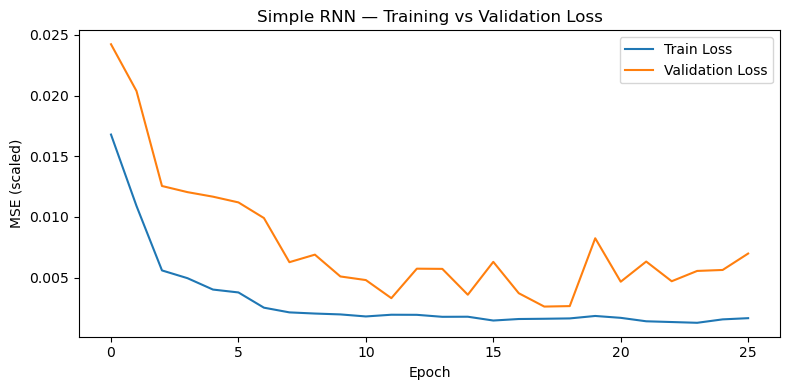

In [76]:
def build_rnn_model():
    model = Sequential([
        Input(shape=(lookback, 1)),
        SimpleRNN(64, return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

rnn_model = build_rnn_model()
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

rnn_history = rnn_model.fit(
    X_train_seq, y_train_seq,
    epochs=60,
    batch_size=32,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stop],
    verbose=0
)

print('Training stopped after', len(rnn_history.history['loss']), 'epochs')

plt.figure(figsize=(8, 4))
plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title('Simple RNN — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
rnn_train_pred_scaled = rnn_model.predict(X_train_seq, verbose=0)
rnn_test_pred_scaled = rnn_model.predict(X_test_seq, verbose=0)

# Inverse-transform back to actual USD price
rnn_train_pred = price_scaler.inverse_transform(rnn_train_pred_scaled).flatten()
rnn_test_pred = price_scaler.inverse_transform(rnn_test_pred_scaled).flatten()
y_train_seq_actual = price_scaler.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
y_test_seq_actual = price_scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

evaluate_model('Simple RNN', y_test_seq_actual, rnn_test_pred, y_train_seq_actual, rnn_train_pred)
pd.DataFrame(model_results).round(4)

,Model,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE (%)
0,Linear Regression,2.7166,12.9498,7.7726,0.9907,2.9831
1,Random Forest,1.1256,130.2676,66.9467,0.0540,16.7500
2,Gradient Boosting,2.2519,127.5439,64.1500,0.0932,15.7481
3,Simple RNN,5.2555,108.0808,61.0952,0.3479,17.0593


## 14. Model 5 — LSTM

**Why:** LSTM (Long Short-Term Memory) networks use gating mechanisms (input, forget, and output gates) to control what information is kept or discarded over time. This helps them retain relevant long-range patterns better than a plain RNN, which is prone to the vanishing gradient problem on longer sequences.

**Architecture:** Same overall shape as the RNN above (two stacked recurrent layers + dropout + dense head), swapping `SimpleRNN` for `LSTM`, so the comparison isolates the effect of the recurrent cell type.

Training stopped after 12 epochs


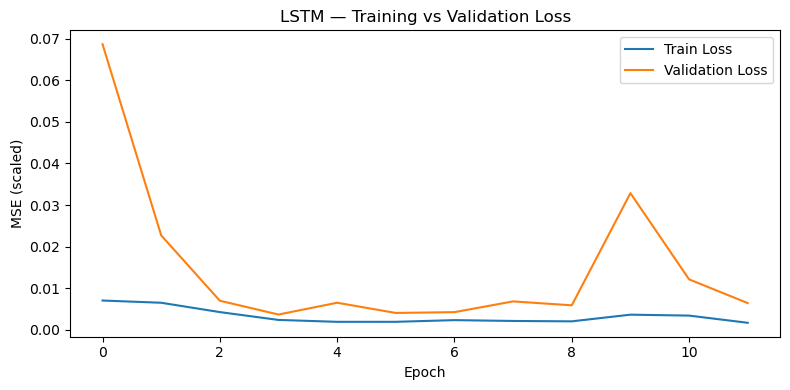

In [78]:
def build_lstm_model():
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_lstm_model()
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=60,
    batch_size=32,
    validation_split=0.15,
    shuffle=False,
    callbacks=[early_stop_lstm],
    verbose=0
)

print('Training stopped after', len(lstm_history.history['loss']), 'epochs')

plt.figure(figsize=(8, 4))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

In [79]:
lstm_train_pred_scaled = lstm_model.predict(X_train_seq, verbose=0)
lstm_test_pred_scaled = lstm_model.predict(X_test_seq, verbose=0)

lstm_train_pred = price_scaler.inverse_transform(lstm_train_pred_scaled).flatten()
lstm_test_pred = price_scaler.inverse_transform(lstm_test_pred_scaled).flatten()

evaluate_model('LSTM', y_test_seq_actual, lstm_test_pred, y_train_seq_actual, lstm_train_pred)
pd.DataFrame(model_results).round(4)

,Model,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE (%)
0,Linear Regression,2.7166,12.9498,7.7726,0.9907,2.9831
1,Random Forest,1.1256,130.2676,66.9467,0.0540,16.7500
2,Gradient Boosting,2.2519,127.5439,64.1500,0.0932,15.7481
3,Simple RNN,5.2555,108.0808,61.0952,0.3479,17.0593
4,LSTM,7.6043,111.8139,64.7244,0.3021,18.7696


# Phase 4: Final Evaluation, Model Comparison & Next-Day Prediction

## 15. Compare All Models

Models are ranked by **Test RMSE** (lower is better) — this is the standard error metric for regression and is in the same units as the stock price (USD).

In [80]:
results_df = pd.DataFrame(model_results).sort_values(by='Test RMSE').reset_index(drop=True)
results_df.round(4)

,Model,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE (%)
0,Linear Regression,2.7166,12.9498,7.7726,0.9907,2.9831
1,Simple RNN,5.2555,108.0808,61.0952,0.3479,17.0593
2,LSTM,7.6043,111.8139,64.7244,0.3021,18.7696
3,Gradient Boosting,2.2519,127.5439,64.1500,0.0932,15.7481
4,Random Forest,1.1256,130.2676,66.9467,0.0540,16.7500


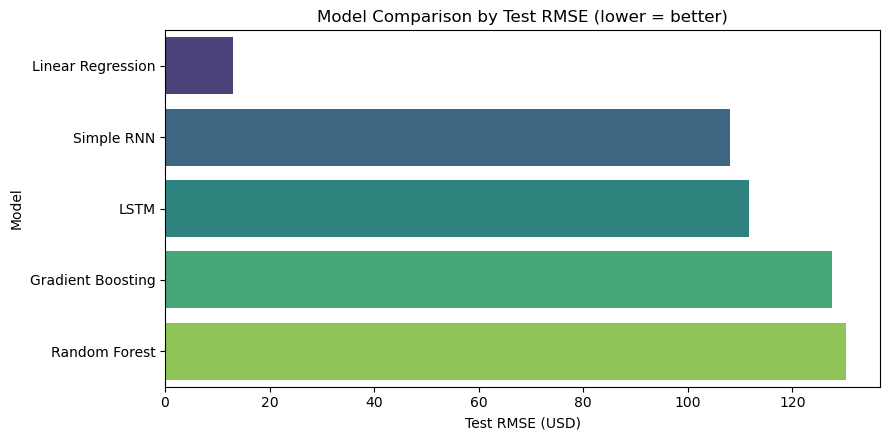

In [81]:
plt.figure(figsize=(9, 4.5))
sns.barplot(data=results_df, x='Test RMSE', y='Model', hue='Model', palette='viridis', legend=False)
plt.title('Model Comparison by Test RMSE (lower = better)')
plt.xlabel('Test RMSE (USD)')
plt.tight_layout()
plt.show()

### Interpreting the comparison

- **Random Forest and Gradient Boosting** tend to perform worst here. AMD's price rose sharply over the dataset's time span, and because of the chronological split, the test set's price range is often higher than what these tree-based models ever saw during training. Trees can only output values within the range of their training targets — they **cannot extrapolate** upward.
- **Linear Regression** performs strongly because a linear function can keep extending in the same direction indefinitely, and the engineered lag/moving-average features are almost linearly related to tomorrow's price.
- **RNN and LSTM** learn directly from the raw price sequence with no hand-engineered features. The LSTM's gating mechanism typically lets it track the recent trend more reliably than the Simple RNN, which is more prone to losing information over the 20-day window (vanishing gradient effect). Neither is guaranteed to beat a well-specified linear model on a relatively short, single-feature series like this one — deep sequence models tend to show their advantage more clearly with longer sequences, more input features, and larger datasets.

## 16. Select the Best Model

In [82]:
best_model_name = results_df.loc[0, 'Model']
print('Best model based on Test RMSE:', best_model_name)
print(results_df[results_df['Model'] == best_model_name].round(4).to_string(index=False))

is_sequence_model = best_model_name in ['Simple RNN', 'LSTM']

Best model based on Test RMSE: Linear Regression
            Model  Train RMSE  Test RMSE  Test MAE  Test R2  Test MAPE (%)
Linear Regression      2.7166    12.9498    7.7726   0.9907         2.9831


## 17. Actual vs. Predicted Price on the Test Set

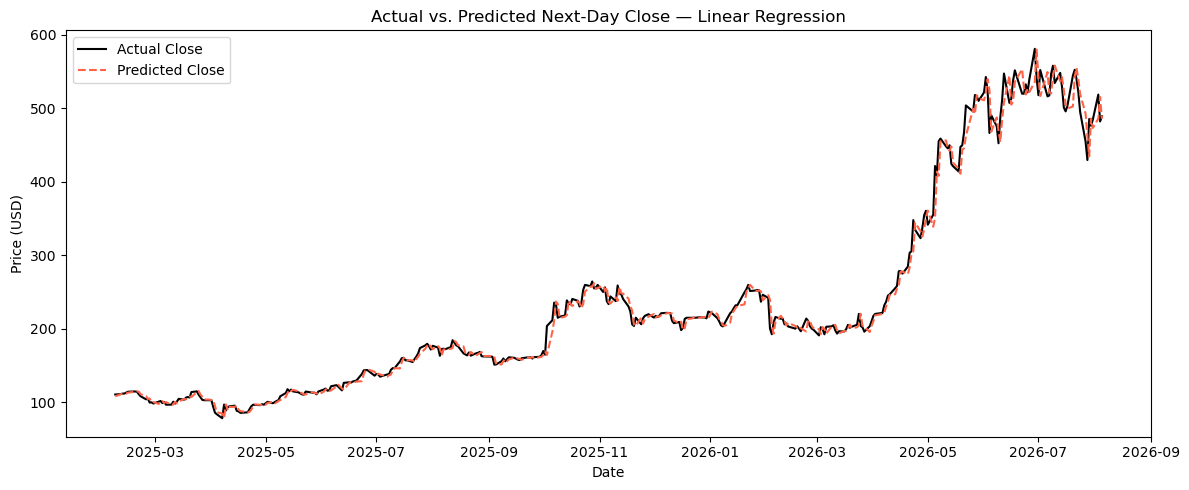

In [83]:
if is_sequence_model:
    best_test_pred = rnn_test_pred if best_model_name == 'Simple RNN' else lstm_test_pred
    plot_dates = pd.to_datetime(dates_test_seq)
    plot_actual = y_test_seq_actual
else:
    best_model_lookup = {
        'Linear Regression': lr_pipeline,
        'Random Forest': rf_best,
        'Gradient Boosting': gb_best
    }
    best_model = best_model_lookup[best_model_name]
    best_test_pred = best_model.predict(X_test)
    plot_dates = dates_test
    plot_actual = y_test.values

plt.figure(figsize=(12, 5))
plt.plot(plot_dates, plot_actual, label='Actual Close', color='black', linewidth=1.5)
plt.plot(plot_dates, best_test_pred, label='Predicted Close', color='tomato', linewidth=1.5, linestyle='--')
plt.title(f'Actual vs. Predicted Next-Day Close — {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

## 18. Residual Analysis

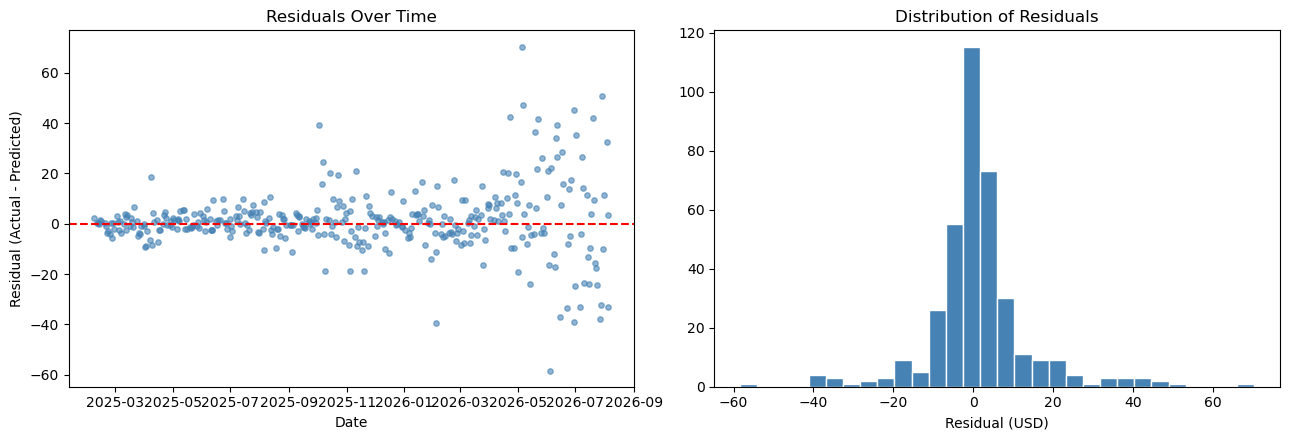

Mean residual: 1.2827
Std of residuals: 12.8862


In [84]:
residuals = plot_actual - best_test_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(plot_dates, residuals, alpha=0.6, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residual (Actual - Predicted)')

axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual (USD)')

plt.tight_layout()
plt.show()

print('Mean residual:', round(residuals.mean(), 4))
print('Std of residuals:', round(residuals.std(), 4))

## 19. Final Next-Day Price Prediction

Using the **most recent data available** (the last date in the dataset, which has no known "next day" yet), we generate the winning model's actual prediction for AMD's next trading day closing price.

In [86]:
import numpy as np
import pandas as pd

# Get latest known date
last_known_date = df['Date'].iloc[-1]

# Make sure closing price is a single number
last_known_close = df['Close'].iloc[-1]

if isinstance(last_known_close, pd.Series):
    last_known_close = last_known_close.iloc[0]

last_known_close = float(last_known_close)

# NEXT-DAY PREDICTION

if is_sequence_model:

    model_used = (
        rnn_model
        if best_model_name == 'Simple RNN'
        else lstm_model
    )

    last_sequence = scaled_close[-lookback:].reshape(1, lookback, 1)

    next_day_scaled = model_used.predict(
        last_sequence,
        verbose=0
    )

    next_day_prediction = price_scaler.inverse_transform(
        next_day_scaled
    )[0, 0]

else:

    latest_features = latest_row[feature_cols]

    next_day_prediction = best_model.predict(
        latest_features
    )[0]


# Make sure prediction is also a single number
if isinstance(next_day_prediction, (pd.Series, np.ndarray)):
    next_day_prediction = np.asarray(next_day_prediction).flatten()[0]

next_day_prediction = float(next_day_prediction)

# CALCULATE PRICE CHANGE

predicted_change = next_day_prediction - last_known_close

predicted_change_pct = (
    predicted_change / last_known_close
) * 100

# DISPLAY RESULT

print('=' * 55)
print(f'Model used for prediction : {best_model_name}')
print(
    f'Last known trading date   : '
    f'{pd.to_datetime(last_known_date).date()}'
)
print(
    f'Last known closing price  : '
    f'${last_known_close:,.2f}'
)

print('-' * 55)

print(
    f'Predicted NEXT-DAY closing price : '
    f'${next_day_prediction:,.2f}'
)

print(
    f'Predicted change                 : '
    f'{predicted_change:+.2f} USD '
    f'({predicted_change_pct:+.2f}%)'
)

print('=' * 55)

Model used for prediction : Linear Regression
Last known trading date   : 2026-08-06
Last known closing price  : $489.28
-------------------------------------------------------
Predicted NEXT-DAY closing price : $492.54
Predicted change                 : +3.26 USD (+0.67%)


## 20. Summary

| Step | Outcome |
|---|---|
| Data | 2,009 daily AMD OHLCV records, no missing values |
| Feature engineering | Lag prices, moving averages, volatility, RSI, spreads, volume change, day of week (tabular models); raw 20-day price sequences (RNN/LSTM) |
| Split | Chronological 85/15 train/test split reused consistently across all models (no shuffling, to avoid time-series leakage) |
| Models compared | Linear Regression, Random Forest, Gradient Boosting, Simple RNN, LSTM |
| Best model | Selected by lowest Test RMSE|
| Key finding | Tree-based models (Random Forest, Gradient Boosting) underperform because AMD's price trended well beyond its historical range and trees cannot extrapolate. Linear Regression and the recurrent models (RNN/LSTM) handle the trending series far better. |
| Deliverable | Next-day closing price prediction generated from the latest available trading day |

### Limitations
- The tabular models use only price/volume-derived technical features; the RNN/LSTM use only the raw closing price sequence — no macroeconomic, news, or earnings data is included in any model.
- Stock prices are influenced by unpredictable external events; no model can reliably predict short-term price moves with high precision.
- A high R² partly reflects that tomorrow's price is naturally close to today's price (a naive "predict no change" baseline would already score well) — models should be judged on whether they beat that baseline, not on R² alone.
- Deep learning models (RNN/LSTM) typically need much more data and more epochs of tuning than used here to reach their full potential; results could shift with more extensive tuning.

### Possible Future Improvements
- Predict daily **returns** instead of price level, which removes the easy "yesterday's price" shortcut.
- Feed multiple engineered features (not just Close) into the RNN/LSTM as a multivariate sequence.
- Try walk-forward validation (retraining periodically) instead of a single static split.
- Incorporate sentiment or macroeconomic features (interest rates, sector indices).
